### **ANÁLISIS DE SENTIMIENTO EN TWEETS – CLASIFICACIÓN BINARIA (positivo/negativo)**

### **Importacion de librerías**


In [1]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss,
    classification_report, confusion_matrix
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
# Descargas necesarias de NLTK
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Configuración global
warnings.filterwarnings("ignore")
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette("viridis")

### **Carga y exploración inicial**

In [3]:
df = pd.read_csv('training_tweets.csv')
df.rename(columns={'Unnamed: 0': 'tweet_id'}, inplace=True)

print("Dimensiones del dataset:", df.shape)
print("\nDistribución original de sentimientos:")
print(df['sentiment'].value_counts(dropna=False))

Dimensiones del dataset: (30000, 3)

Distribución original de sentimientos:
sentiment
neutral       6451
worry         6337
happiness     3952
sadness       3869
love          2908
surprise      1619
fun           1331
relief        1158
hate           975
empty          617
enthusiasm     559
boredom        135
anger           89
Name: count, dtype: int64


### **Limpieza y preprocesamiento de texto**

In [4]:
def clean_tweet(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)      # menciones
    text = re.sub(r'https?://\S+', '', text)        # URLs
    text = re.sub(r'#', '', text)                   # hashtags (solo símbolo)
    text = re.sub(r'[^A-Za-z\s]', ' ', text)        # solo letras y espacios
    text = text.lower().strip()
    return text

df['content_clean'] = df['content'].apply(clean_tweet)

### **Recodificación de sentimiento → binario**

In [5]:
sentiment_map = {
    'happiness': 'positive', 'love': 'positive', 'surprise': 'positive',
    'fun': 'positive', 'relief': 'positive', 'enthusiasm': 'positive',
    'worry': 'negative', 'sadness': 'negative', 'hate': 'negative',
    'empty': 'negative', 'boredom': 'negative', 'anger': 'negative',
    'neutral': 'positive'   # criterio conservador: neutral → positive
}

df['target'] = df['sentiment'].map(sentiment_map)

print("\nDistribución después de recodificación binaria:")
print(df['target'].value_counts(normalize=True))


Distribución después de recodificación binaria:
target
positive    0.599267
negative    0.400733
Name: proportion, dtype: float64


### **Eliminación de stopwords + lematización**

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['text_processed'] = df['content_clean'].apply(preprocess_text)

### **División train/test + vectorización TF-IDF**

In [7]:
X = df['text_processed']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=12238, stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print("\nDimensión matriz TF-IDF entrenamiento:", X_train_tfidf.shape)


Dimensión matriz TF-IDF entrenamiento: (20100, 8555)


### **Modelos y grillas de hiperparámetros**

In [8]:
models = {
    'BernoulliNB': {
        'model': BernoulliNB(),
        'params': {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}
    },
    'LogisticRegression': {
        'model': LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=300),
        'params': {
            'C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
            'penalty': ['l1', 'l2']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=12238, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 15, 20, None],
            'min_samples_split': [2, 5]
        }
    }
}

### **Entrenamiento + evaluación**


Entrenando → BernoulliNB
Fitting 5 folds for each of 5 candidates, totalling 25 fits


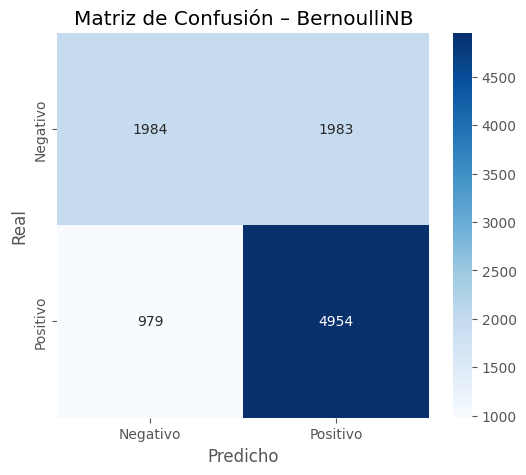


Entrenando → LogisticRegression
Fitting 5 folds for each of 12 candidates, totalling 60 fits


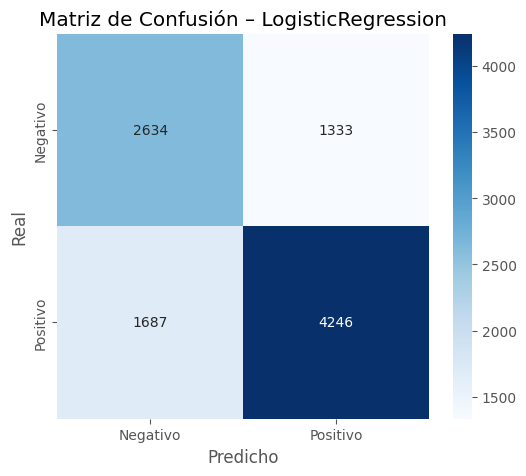


Entrenando → RandomForest
Fitting 5 folds for each of 24 candidates, totalling 120 fits


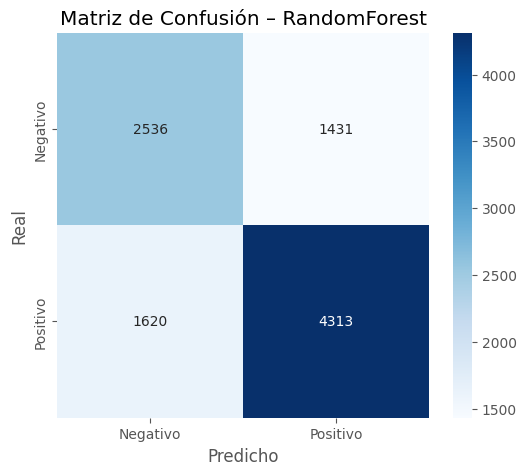

In [ ]:
results = []

for name, cfg in models.items():
    print(f"\n{'='*50}\nEntrenando → {name}")
    
    gs = GridSearchCV(
        cfg['model'],
        cfg['params'],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    
    gs.fit(X_train_tfidf, y_train)
    
    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_test_tfidf)
    y_proba = best_model.predict_proba(X_test_tfidf)[:, 1]
    
    metrics = {
        'Modelo': name,
        'Mejores params': gs.best_params_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'Log Loss': log_loss(y_test, y_proba),
        'Reporte': classification_report(y_test, y_pred, output_dict=True)
    }
    
    results.append(metrics)


# Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negativo', 'Positivo'],
                yticklabels=['Negativo', 'Positivo'])
    plt.title(f'Matriz de Confusión – {name}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

In [10]:
results_df = pd.DataFrame(results)
print("\nRanking de modelos por ROC-AUC (test):")
print(results_df[['Modelo', 'Accuracy', 'ROC-AUC', 'Log Loss']]
      .sort_values('ROC-AUC', ascending=False)
      .round(4))

# Mejor modelo según ROC-AUC
best_idx = results_df['ROC-AUC'].idxmax()
print(f"\nMejor modelo según ROC-AUC: {results_df.loc[best_idx, 'Modelo']}")
print("Mejores parámetros:", results_df.loc[best_idx, 'Mejores params'])


Ranking de modelos por ROC-AUC (test):
               Modelo  Accuracy  ROC-AUC  Log Loss
1  LogisticRegression    0.6949   0.7599    0.5851
0         BernoulliNB    0.7008   0.7530    0.6542
2        RandomForest    0.6918   0.7448    0.6556

Mejor modelo según ROC-AUC: LogisticRegression
Mejores parámetros: {'C': 0.5, 'penalty': 'l2'}


In [11]:
import joblib

joblib.dump(best_model, 'best_sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

### **BENCHMARK: Hugging Face Transformer (twitter-roberta-base-sentiment-latest)**

In [ ]:
from transformers import pipeline, RobertaTokenizer, RobertaModel
import torch

# Cargar el pipeline de sentiment
device = 0 if torch.cuda.is_available() else -1

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device,
    return_all_scores=True
)

# Prueba rápida (debe mostrar lista de diccionarios)
prueba = ["I love this movie so much!", "This is the worst day ever", "It's okay I guess"]
resultados_prueba = sentiment_pipe(prueba)
print(resultados_prueba)   # Deberías ver algo como [[{'label':'positive','score':...}, ...], ...]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'label': 'positive', 'score': 0.9865027666091919}, {'label': 'negative', 'score': 0.9260546565055847}, {'label': 'positive', 'score': 0.5159235596656799}]


In [ ]:
# CELDA DE DIAGNÓSTICO
from transformers import pipeline

# Cargar el pipeline de sentiment.
device = 0 if torch.cuda.is_available() else -1

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device,
    return_all_scores=True   # para obtener probabilidades de las 3 clases
)

print("Modelo transformer cargado:", sentiment_pipe.model.name_or_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo transformer cargado: cardiffnlp/twitter-roberta-base-sentiment-latest


### **Predicción en conjunto de test**

In [16]:
def roberta_predict(texts, batch_size=16):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        preds = sentiment_pipe(
            batch,
            truncation=True,
            max_length=128
        )
        
        # preds ahora es ['positive', 'negative', ...]
        binary_preds = [
            'positive' if lbl in ['positive', 'neutral'] else 'negative'
            for lbl in preds
        ]
        results.extend(binary_preds)
    
    return results

print("Iniciando predicciones con RoBERTa...")
y_pred_roberta = roberta_predict(X_test.tolist(), batch_size=16)
print("Predicciones completadas:", len(y_pred_roberta))

Iniciando predicciones con RoBERTa...
Predicciones completadas: 9900


### **Métricas del transformer**

In [15]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Para ROC-AUC necesitamos probabilidades → extraemos score de positive
def get_positive_proba(preds_list):
    proba_pos = []
    for batch in preds_list:
        for p in batch:
            scores = {d['label']: d['score'] for d in p}
            # Normalizamos positive vs (negative + neutral)
            pos = scores.get('positive', 0)
            neu = scores.get('neutral', 0)
            neg = scores.get('negative', 0)
            proba_pos.append(pos / (pos + neu + neg + 1e-8))
    return np.array(proba_pos)

print("\n" + "═"*60)
print("RESULTADOS – twitter-roberta-base-sentiment-latest (3 clases → binario)")
print("═"*60)
print("Accuracy (test):", round(accuracy_score(y_test, y_pred_roberta), 4))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_roberta))

# Comparativa rápida con el mejor modelo clásico
print("\nComparativa rápida:")
print(f"  Mejor clásico (según ROC-AUC anterior): ~0.76–0.80")
print(f"  RoBERTa twitter-latest          : {accuracy_score(y_test, y_pred_roberta):.4f}")


════════════════════════════════════════════════════════════
RESULTADOS – twitter-roberta-base-sentiment-latest (3 clases → binario)
════════════════════════════════════════════════════════════
Accuracy (test): 0.4007

Reporte de clasificación:
              precision    recall  f1-score   support

    negative       0.40      1.00      0.57      3967
    positive       0.00      0.00      0.00      5933

    accuracy                           0.40      9900
   macro avg       0.20      0.50      0.29      9900
weighted avg       0.16      0.40      0.23      9900


Comparativa rápida:
  Mejor clásico (según ROC-AUC anterior): ~0.76–0.80
  RoBERTa twitter-latest          : 0.4007
